## 1 · Imports & global config

In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

# ─── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── Config ──────────────────────────────────────────────────

CFG = dict(
    data_dir        = '/content/drive/MyDrive/skin_cnn_project/input',
    img_dirs        = ['/content/drive/MyDrive/skin_cnn_project/input/HAM10000_images_part_1',
                       '/content/drive/MyDrive/skin_cnn_project/input/HAM10000_images_part_2'],
    img_size        = 224,
    batch_size      = 32,
    num_workers     = 0,
    num_classes     = 7,
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    patience        = 10,
    dropout         = 0.5,

    # Imbalance strategy
    imbalance_strategy = 'none',

    use_pretrained  = False,
    checkpoint_path = 'best_model.pth',
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# DEVICE = torch.device('mps' if torch.mps.is_available() else 'cpu')
# print(f"Device: {DEVICE}")

LABEL_MAP = {'nv':4,'mel':5,'bkl':2,'bcc':1,'akiec':0,'vasc':6,'df':3}
CLASS_NAMES = list(LABEL_MAP.keys())

Device: cuda


In [ ]:
LABEL_MAP

{'nv': 4, 'mel': 5, 'bkl': 2, 'bcc': 1, 'akiec': 0, 'vasc': 6, 'df': 3}

## 2 · Load metadata & EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Total samples : 10015
Unique lesions: 7470

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


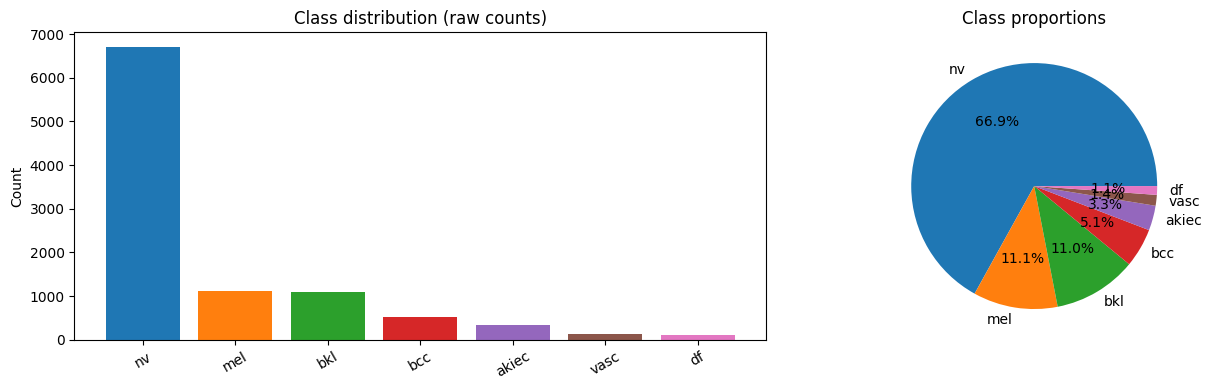


Imbalance ratio (max/min): 58.3x


In [ ]:
df = pd.read_csv(os.path.join(CFG['data_dir'], 'HAM10000_metadata.csv'))
df['label'] = df['dx'].map(LABEL_MAP)

print(f"Total samples : {len(df)}")
print(f"Unique lesions: {df['lesion_id'].nunique()}")
print(f"\nClass distribution:")
print(df['dx'].value_counts())

# ─── Plot class distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df['dx'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('tab10', 7))
axes[0].set_title('Class distribution (raw counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('tab10', 7))
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")

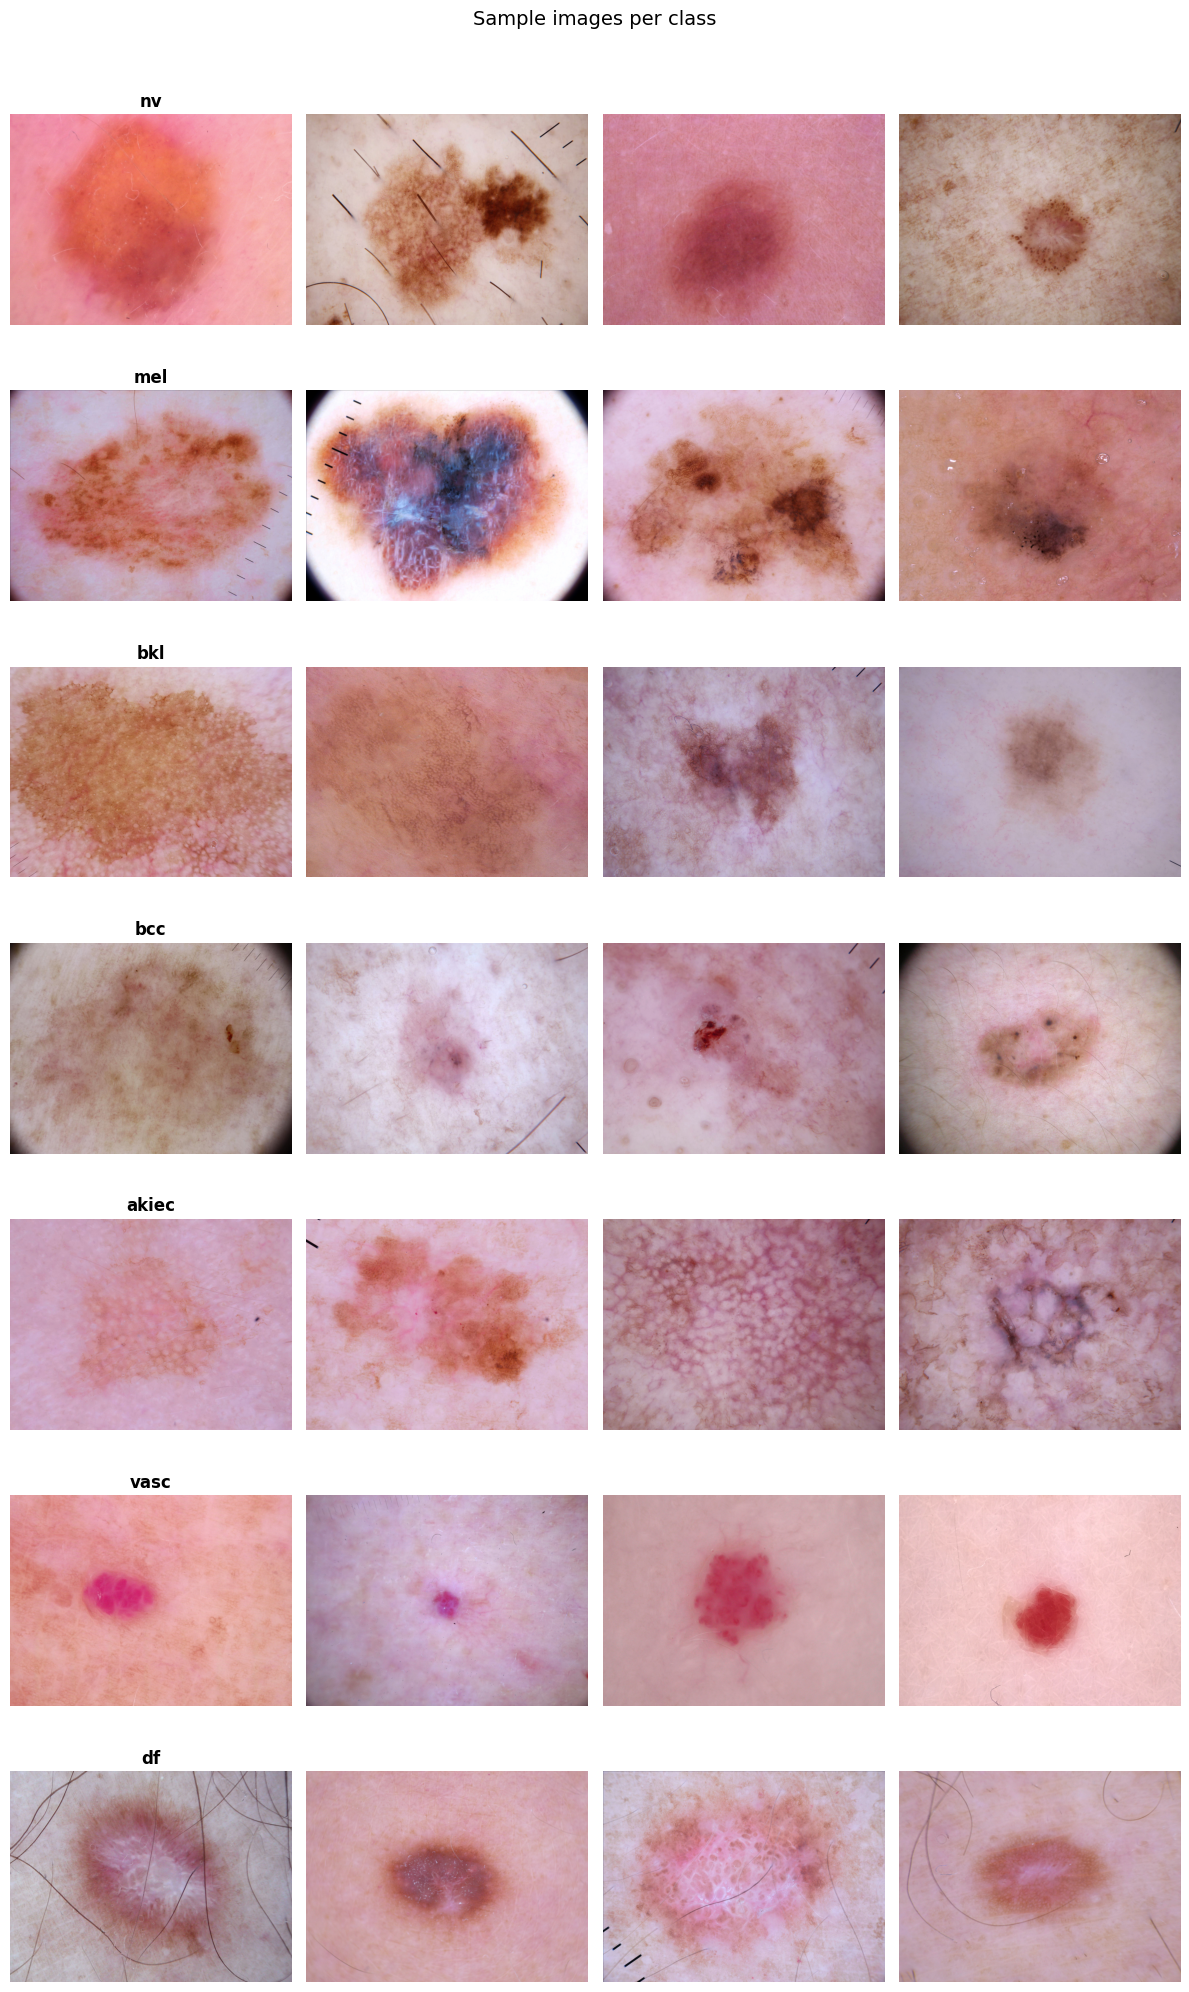

In [ ]:
# ─── Sample images per class ─────────────────────────────────
def find_image(image_id, img_dirs):
    for d in img_dirs:
        p = os.path.join(d, f"{image_id}.jpg")
        if os.path.exists(p):
            return p
    raise FileNotFoundError(image_id)

fig, axes = plt.subplots(7, 4, figsize=(12, 20))
for row_idx, cls in enumerate(CLASS_NAMES):
    samples = df[df['dx'] == cls].sample(min(4, len(df[df['dx']==cls])), random_state=SEED)
    for col_idx, (_, s) in enumerate(samples.iterrows()):
        try:
            img = Image.open(find_image(s['image_id'], CFG['img_dirs']))
            axes[row_idx, col_idx].imshow(img)
        except FileNotFoundError:
            axes[row_idx, col_idx].text(0.5, 0.5, 'not found',
                                         ha='center', va='center')
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(cls, fontsize=12, fontweight='bold')
plt.suptitle('Sample images per class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3 · Train / Val / Test split

> ⚠️ **Critical:** Split on `lesion_id`, not `image_id`. Some lesions have multiple photos — naive splitting causes data leakage.

In [ ]:
unique_lesions = df.drop_duplicates('lesion_id')[['lesion_id','label']]

train_ids, temp_ids = train_test_split(
    unique_lesions, test_size=0.30,
    stratify=unique_lesions['label'], random_state=SEED
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50,
    stratify=temp_ids['label'], random_state=SEED
)

train_df = df[df['lesion_id'].isin(train_ids['lesion_id'])].reset_index(drop=True)
val_df   = df[df['lesion_id'].isin(val_ids['lesion_id'])  ].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_ids['lesion_id']) ].reset_index(drop=True)

print(f"Train: {len(train_df):>5}  |  Val: {len(val_df):>4}  |  Test: {len(test_df):>4}")
print("\nTrain class breakdown:")
print(train_df['dx'].value_counts())

Train:  7034  |  Val: 1486  |  Test: 1495

Train class breakdown:
dx
nv       4711
mel       776
bkl       774
bcc       366
akiec     230
vasc      101
df         76
Name: count, dtype: int64


## 4 · Augmentation pipelines

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SZ = CFG['img_size']

def get_train_transforms():
    return A.Compose([
        A.Resize(SZ, SZ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

print("Transforms defined.")

def get_val_transforms():
    return A.Compose([
        A.Resize(SZ, SZ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

Transforms defined.


## 5 · Dataset class

In [ ]:
class HAMDataset(Dataset):
    """
    Base HAM10000 dataset.
    Returns (tensor, label) where tensor is a float32 CHW image.
    """
    def __init__(self, df: pd.DataFrame, img_dirs: list, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dirs  = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id: str) -> str:
        for d in self.img_dirs:
            p = os.path.join(d, f"{image_id}.jpg")
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f"Image not found: {image_id}")

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self._find_image(row['image_id'])).convert('RGB')
        img   = np.array(img)           # albumentations expects numpy uint8 HWC
        label = int(row['label'])

        if self.transform:
            img = self.transform(image=img)['image']   # → CHW float32 tensor

        return img, label


class HAMDatasetOversample(Dataset):
    """
    Strategy: augmentation-based oversampling.
    Minority classes are repeated so every class reaches
    `target_count` samples. Repeated rows get `heavy_transform`.
    """
    def __init__(self, df: pd.DataFrame, img_dirs: list,
                 base_transform, heavy_transform,
                 target_count: int = None):
        counts        = df['label'].value_counts()
        target_count  = target_count or int(counts.max())

        frames, is_augmented = [], []
        for lbl, grp in df.groupby('label'):
            frames.append(grp)
            is_augmented.extend([False] * len(grp))
            shortage = target_count - len(grp)
            if shortage > 0:
                extra = grp.sample(shortage, replace=True, random_state=SEED)
                frames.append(extra)
                is_augmented.extend([True] * len(extra))

        self.df            = pd.concat(frames).reset_index(drop=True)
        self.is_augmented  = is_augmented
        self.img_dirs      = img_dirs
        self.base_tf       = base_transform
        self.heavy_tf      = heavy_transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id):
        for d in self.img_dirs:
            p = os.path.join(d, f"{image_id}.jpg")
            if os.path.exists(p):
                return p
        raise FileNotFoundError(image_id)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = np.array(Image.open(self._find_image(row['image_id'])).convert('RGB'))
        label = int(row['label'])
        tf    = self.heavy_tf if self.is_augmented[idx] else self.base_tf
        return tf(image=img)['image'], label


print("Dataset classes defined.")

Dataset classes defined.


## 6 · Imbalance helpers

In [ ]:
def get_class_weights(train_df: pd.DataFrame, num_classes: int = 7) -> torch.Tensor:
    """sklearn balanced class weights → torch tensor."""
    labels = train_df['label'].values
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(num_classes),
        y=labels
    )
    print("Class weights:")
    for name, w in zip(CLASS_NAMES, weights):
        print(f"  {name:>6}: {w:.4f}")
    return torch.FloatTensor(weights)


def get_weighted_sampler(train_df: pd.DataFrame) -> WeightedRandomSampler:
    """Per-sample weights so every class is equally probable per batch."""
    labels        = train_df['label'].values
    class_counts  = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(
        weights     = torch.DoubleTensor(sample_weights),
        num_samples = len(sample_weights),
        replacement = True
    )


print("Imbalance helpers defined.")

Imbalance helpers defined.


## 7 · Build DataLoaders

In [ ]:
strategy = CFG['imbalance_strategy']
print(f"Imbalance strategy: {strategy}")

val_transform  = get_val_transforms()
train_sampler  = None
shuffle_train  = True

# ── Augmentation oversampling ──
if strategy == 'augment_oversample':
    train_dataset = HAMDatasetOversample(
        train_df, CFG['img_dirs'],
        base_transform  = get_train_transforms(),
        heavy_transform = get_heavy_transforms(),
    )
else:
    train_dataset = HAMDataset(train_df, CFG['img_dirs'],
                               transform=get_train_transforms())

# ── WeightedRandomSampler ──
if strategy == 'sampler':
    train_sampler = get_weighted_sampler(train_df)
    shuffle_train = False        # sampler and shuffle are mutually exclusive

val_dataset  = HAMDataset(val_df,   CFG['img_dirs'], transform=val_transform)
test_dataset = HAMDataset(test_df,  CFG['img_dirs'], transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG['batch_size'],
    sampler     = train_sampler,
    shuffle     = shuffle_train if train_sampler is None else False,
    num_workers = CFG['num_workers'],
    pin_memory  = False, #pin_memory requires CUDA workers
)


val_loader  = DataLoader(val_dataset,  batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Imbalance strategy: none
Train batches: 220 | Val batches: 47 | Test batches: 47


## 8 · Model definition

In [ ]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class BaselineCNN(nn.Module):
    """
    4-block encoder → Adaptive avg pool → 512-d head → 7-way classifier.
    The `feature_extractor` attribute exposes the 512-d embedding,
    which is used by the SMOTE workflow.
    """
    def __init__(self, num_classes: int = 7, dropout: float = 0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3,    32), nn.MaxPool2d(2),   # 112×112
            ConvBlock(32,   64), nn.MaxPool2d(2),   #  56×56
            ConvBlock(64,  128), nn.MaxPool2d(2),   #  28×28
            ConvBlock(128, 256), nn.MaxPool2d(2),   #  14×14
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))    # → 256×4×4
        self.feature_extractor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.encoder(x)
        x = self.pool(x)
        feats = self.feature_extractor(x)
        return self.classifier(feats)

    def get_features(self, x):
        """Return 512-d embedding (for SMOTE)."""
        x = self.encoder(x)
        x = self.pool(x)
        return self.feature_extractor(x)


def get_pretrained_model(num_classes: int = 7, freeze_backbone: bool = False):
    """
    ResNet-18 with ImageNet weights.
    Set freeze_backbone=True to train only the head first.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    # expose feature extractor for SMOTE compatibility
    def get_features(self, x):
        x = self.conv1(x); x = self.bn1(x); x = self.relu(x); x = self.maxpool(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        return self.avgpool(x).flatten(1)
    import types
    model.get_features = types.MethodType(get_features, model)
    return model


# ── Build model ───────────────────────────────────────────────
if CFG['use_pretrained']:
    model = get_pretrained_model(CFG['num_classes']).to(DEVICE)
    print("Using pretrained ResNet-18")
else:
    model = BaselineCNN(CFG['num_classes'], CFG['dropout']).to(DEVICE)
    print("Using scratch BaselineCNN")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Using scratch BaselineCNN
Trainable parameters: 3,274,471


## 9 · Loss function & optimizer

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Loss ─────────────────────────────────────────────────────
if strategy == 'class_weight':
    weights   = get_class_weights(train_df, CFG['num_classes']).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    print("Loss: weighted CrossEntropyLoss")
else:
    criterion = nn.CrossEntropyLoss()
    print("Loss: standard CrossEntropyLoss")

# ── Optimizer ─────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max   = CFG['epochs'],
    eta_min = 1e-6,
)

print(f"Optimizer : AdamW  lr={CFG['lr']}  wd={CFG['weight_decay']}")
print(f"Scheduler : CosineAnnealingLR  T_max={CFG['epochs']}")

Loss: standard CrossEntropyLoss
Optimizer : AdamW  lr=0.001  wd=0.0001
Scheduler : CosineAnnealingLR  T_max=50


## 10 · Training loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = n = 0
    bar = tqdm(loader, leave=False, desc='  train')
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        bs          = labels.size(0)
        total_loss += loss.item() * bs
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += bs
        bar.set_postfix(loss=f"{total_loss/n:.4f}", acc=f"{correct/n:.3f}")
    return total_loss / n, correct / n


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = n = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False, desc='    val'):
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)

            bs          = labels.size(0)
            total_loss += loss.item() * bs
            preds       = logits.argmax(1)
            correct    += (preds == labels).sum().item()
            n          += bs

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return total_loss / n, correct / n, all_preds, all_labels, all_probs


print("Training functions defined.")

Training functions defined.


In [ ]:
history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, preds, gt, probs = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'  ].append(vl_loss)
    history['train_acc' ].append(tr_acc)
    history['val_acc'   ].append(vl_acc)

    # ── Checkpoint ──
    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        torch.save(model.state_dict(), CFG['checkpoint_path'])
        marker = '  ← best'
    else:
        patience_counter += 1
        marker = ''

    print(f"Epoch {epoch:03d}/{CFG['epochs']} "
          f"| train loss {tr_loss:.4f}  acc {tr_acc:.3f} "
          f"| val   loss {vl_loss:.4f}  acc {vl_acc:.3f}"
          f"{marker}")

    if patience_counter >= CFG['patience']:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 001/50 | train loss 1.0652  acc 0.658 | val   loss 0.9201  acc 0.676  ← best


Epoch 002/50 | train loss 0.9119  acc 0.668 | val   loss 0.9173  acc 0.690  ← best


Epoch 003/50 | train loss 0.8860  acc 0.679 | val   loss 0.8316  acc 0.690  ← best


Epoch 004/50 | train loss 0.8618  acc 0.685 | val   loss 0.9056  acc 0.706


Epoch 005/50 | train loss 0.8370  acc 0.694 | val   loss 0.8706  acc 0.692


...

Epoch 033/50 | train loss 0.4890  acc 0.812 | val   loss 0.7014  acc 0.760


Epoch 034/50 | train loss 0.4822  acc 0.820 | val   loss 0.6908  acc 0.765


Epoch 035/50 | train loss 0.4705  acc 0.820 | val   loss 0.7190  acc 0.757


Epoch 036/50 | train loss 0.4670  acc 0.822 | val   loss 0.6969  acc 0.766


Epoch 037/50 | train loss 0.4600  acc 0.821 | val   loss 0.7064  acc 0.766
Early stopping triggered at epoch 37.

Best val loss: 0.6785


## 11 · Training curves

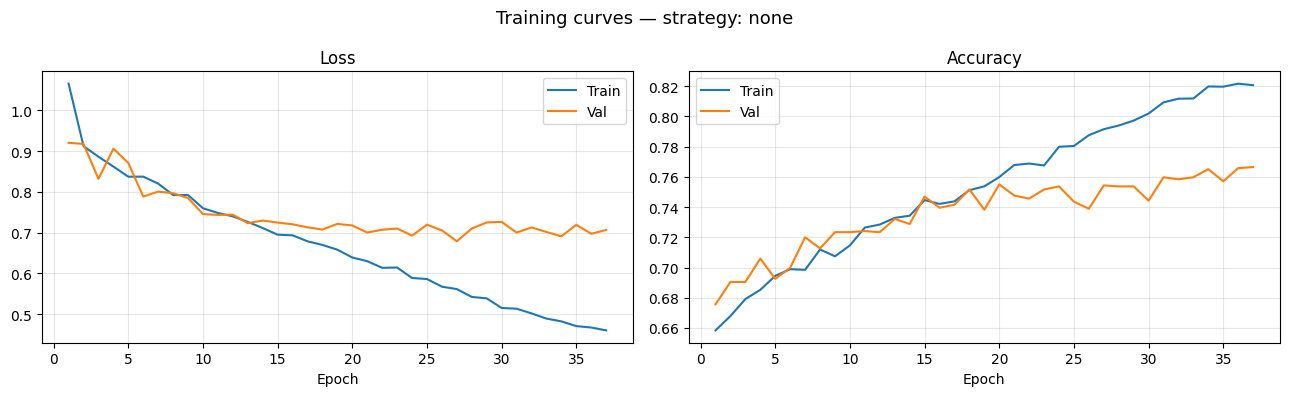

In [ ]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, history['train_loss'], label='Train')
axes[0].plot(x, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x, history['train_acc'], label='Train')
axes[1].plot(x, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Training curves — strategy: {strategy}', fontsize=13)
plt.tight_layout()
plt.show()

## 12 · Evaluate on test set

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CFG['checkpoint_path'], map_location=DEVICE))
_, test_acc, test_preds, test_gt, test_probs = validate(
    model, test_loader, criterion, DEVICE
)

print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(test_gt, test_preds, target_names=CLASS_NAMES, digits=4))

Test accuracy: 0.7592

              precision    recall  f1-score   support

          nv     0.4030    0.5294    0.4576        51
         mel     0.4078    0.5833    0.4800        72
         bkl     0.5547    0.4329    0.4863       164
         bcc     0.0000    0.0000    0.0000        21
       akiec     0.8764    0.9162    0.8959       991
        vasc     0.5282    0.4237    0.4702       177
          df     0.6316    0.6316    0.6316        19

    accuracy                         0.7592      1495
   macro avg     0.4859    0.5025    0.4888      1495
weighted avg     0.7458    0.7592    0.7496      1495



In [ ]:
EXPORT_PATH = "/content/drive/MyDrive/skin_cnn_project/skin_cnn_baseline_model.pt"

# Load best model
model.load_state_dict(torch.load(CFG['checkpoint_path'], map_location=DEVICE))
model.eval()
model.cpu()

# Dummy input (VERY IMPORTANT: must match your model input)
dummy_input = torch.randn(1, 3, 224, 224)

# Export (use scripting because your model is simple & safe)
scripted_model = torch.jit.script(model)

# Save
scripted_model.save(EXPORT_PATH)

In [ ]:
# ── AUC-ROC (macro OvR) ───────────────────────────────────────
y_bin = label_binarize(test_gt, classes=list(range(CFG['num_classes'])))
auc_macro = roc_auc_score(y_bin, test_probs, multi_class='ovr', average='macro')
auc_per_class = roc_auc_score(y_bin, test_probs, multi_class='ovr', average=None)

print(f"Macro AUC-ROC : {auc_macro:.4f}\n")
print("Per-class AUC:")
for name, auc in zip(CLASS_NAMES, auc_per_class):
    print(f"  {name:>6}: {auc:.4f}")

Macro AUC-ROC : 0.9165

Per-class AUC:
      nv: 0.9298
     mel: 0.9416
     bkl: 0.8672
     bcc: 0.8674
   akiec: 0.9267
    vasc: 0.8863
      df: 0.9963


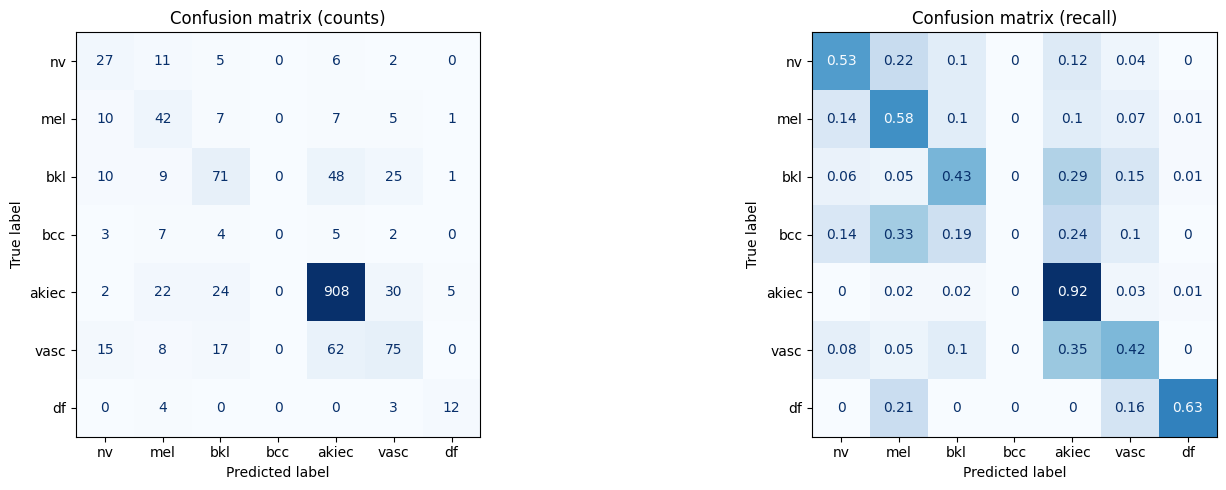

In [ ]:
# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(test_gt, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw counts
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts)')

# Normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (recall)')

plt.tight_layout()
plt.show()